# TD法
教科書P174のコードを試す。

In [12]:
import sys, os
sys.path.append(os.pardir)

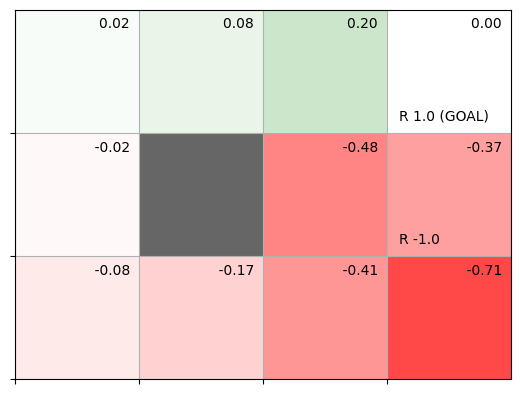

In [13]:
from td_eval import *
from common.gridworld import *

env = GridWorld()
agent = TdAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done) # 毎回呼ぶ
        if done:
            break
        state = next_state

env.render_v(agent.V)

## SarsaAgentクラスを動かす

`deque`を用いているため、`agent.memory`に格納されている第1要素が「現在の状態についての情報」である。

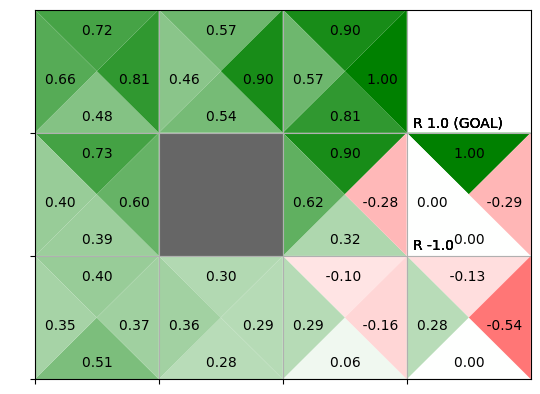

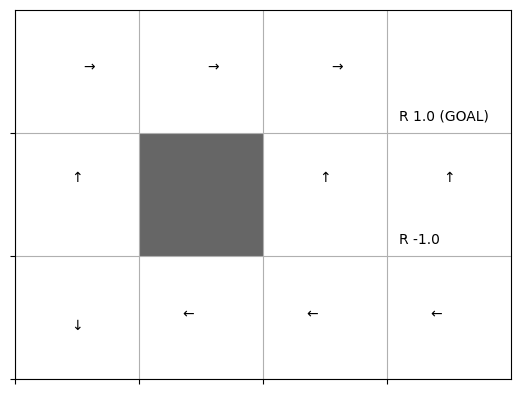

In [14]:
import sys, os
sys.path.append(os.pardir)

from sarsa import SarsaAgent
from common.gridworld import *

env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action) # next_stateがゴールのときに`done = True`となることに注意せよ。

        agent.update(state, action, reward, done)   # 毎回呼ぶ（Agentが進む（行動する）ごとに更新するので）

        if done:
            agent.update(next_state, None, None, None)  # ゴールに到達したときは、その後の行動(action)と報酬(reward)、その次がゴールかどうかの判定(done)に情報はないので、それらは`None`として実装する。
            # そしてSARSAでは、今と次の状態と行動のデータによって更新するので、ゴールに到達したときも、方策を改善する。
            # agent.updateがここで実行されて初めて、現在の状態がagent.memoryインスタンス変数の第0要素へと格納されるため、その状態でQ関数の値を更新することができる（最後のステップで、次の状態がゴールの時の値も考慮されたQ関数の値の更新が可能）。
            break
        state = next_state

env.render_q(agent.Q)

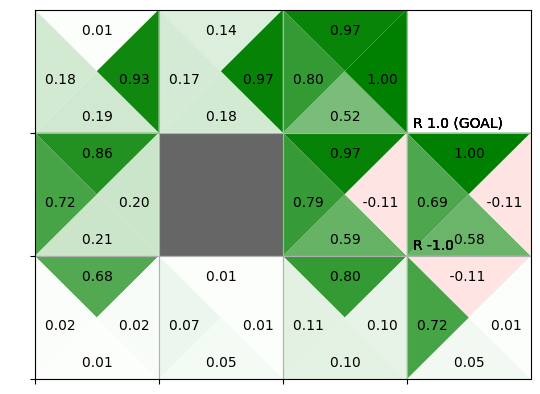

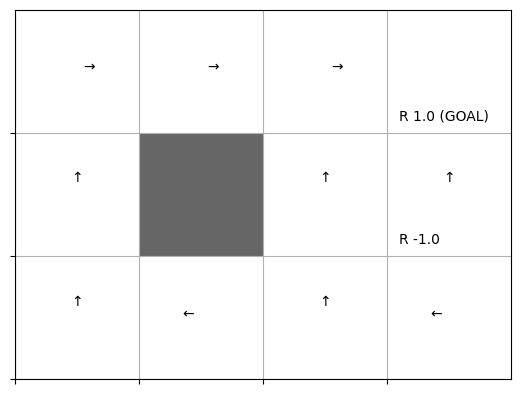

In [15]:
# 教科書通りのコード

import sys, os
sys.path.append(os.pardir)

from sarsa_off_policy import *
from common.gridworld import *

env = GridWorld()
agent_i = SarsaOffPolicyAgent()
# agent_i = NeoSarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent_i.reset()

    while True:
        action = agent_i.get_action(state)
        next_state, reward, done = env.step(action)

        agent_i.update(state, action, reward, done)

        if done:
            agent_i.update(state, None, None, None)
            break

        state = next_state

env.render_q(agent_i.Q)

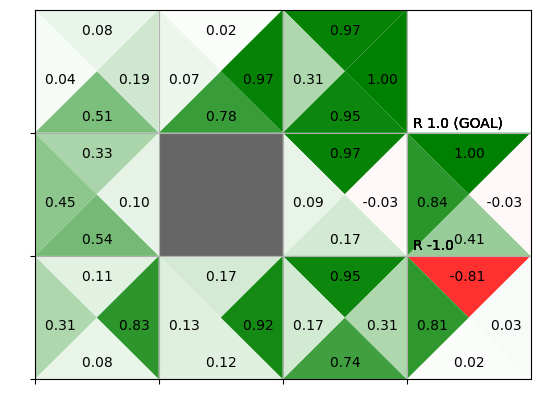

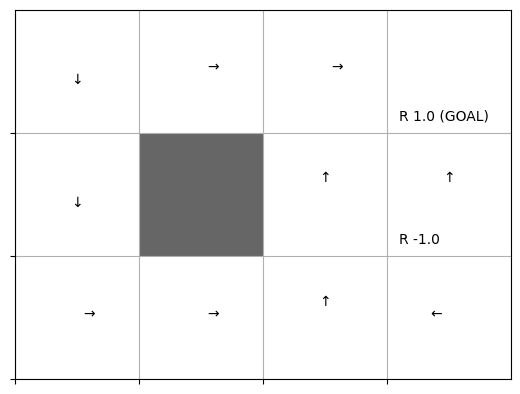

In [16]:
# 教科書から改善したバージョン

import sys, os
sys.path.append(os.pardir)

from sarsa_off_policy import *
from common.gridworld import *

env = GridWorld()
# agent_i = SarsaOffPolicyAgent()
agent_ii = NeoSarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent_ii.reset()

    while True:
        action = agent_ii.get_action(state)
        next_state, reward, done = env.step(action)

        agent_ii.update(state, action, reward, done)

        if done:
            agent_ii.update(state, None, None, None)
            break

        state = next_state

env.render_q(agent_ii.Q)

In [17]:
import numpy as np
q_values_i = list(agent_i.Q.values())
q_values_ii = list(agent_ii.Q.values())

vars_i = np.var(q_values_i)
vars_ii = np.var(q_values_ii)

print(f"variance_i : {vars_i}, variance_ii : {vars_ii}")

variance_i : 0.14210089275034632, variance_ii : 0.1617408469602151
